In [15]:
import cdsapi
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
from zipfile import ZipFile

In [2]:
data_path = r"C:\MIRACA\temperature_data\H_ERA5_ECMW_T639_TA-_0002m_Pecd_025d_S202401010000_E202412312300_INS_MAP_01h_COM_noc_org_NA_NA---_NA---_NA---_PECD4.2_fv1.area-subset.43.-6.31.-31.nc"

In [21]:
data_path = r"C:\MIRACA\temperature_data\H_ERA5_ECMW_T639_TA-_0002m_Pecd_025d_S198101010000_E198112312300_INS_MAP_01h_COM_noc_org_NA_NA---_NA---_NA---_PECD4.2_fv1.area-subset.44.4.5.34.-10.nc"

In [22]:
data = xr.open_dataset(data_path)

In [23]:
# Convert to daily maximum temperatures
daily_max = data.resample(time='1D').max()

In [26]:
daily_max

<xarray.Dataset> Size: 7MB
Dimensions:    (time: 365, latitude: 41, longitude: 59)
Coordinates:
  * longitude  (longitude) float32 236B -10.0 -9.75 -9.5 -9.25 ... 4.0 4.25 4.5
  * latitude   (latitude) float32 164B 44.0 43.75 43.5 43.25 ... 34.5 34.25 34.0
  * time       (time) datetime64[ns] 3kB 1981-01-01 1981-01-02 ... 1981-12-31
Data variables:
    t2m        (time, latitude, longitude) float64 7MB 285.8 285.8 ... 295.0
Attributes:
    title:        2 metre temperature; data for ENTSO-E PECD Version 4.2; fil...
    institution:  Copernicus Climate Change Service, Sectoral Information Sys...
    source:       ERA5 reanalysis data provided by ECMWF (https://www.ecmwf.i...
    history:      2024-09-20 10:57:15 GMT by write_hist_xr_to_nc-0.1.dev51+g1...
    references:   
    Conventions:  CF-1.12-draft

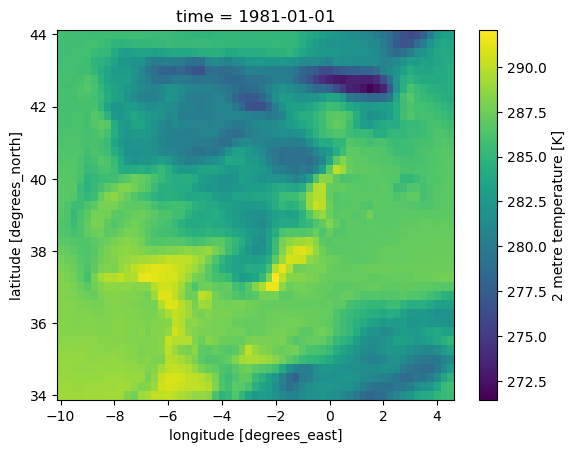

In [27]:
daily_max.sel(time='1981-01-01')['t2m'].plot()

In [28]:
def calculate_PG_from_daily_max(dataset):
    """
    Calculate Performance Grade from daily maximum temperature data
    
    Parameters:
    dataset: xarray Dataset with 't2m' variable containing daily max temperatures in Kelvin
             Dimensions: (time, latitude, longitude)
    """
    
    # Step 1: Extract temperature data and convert from Kelvin to Celsius
    temp_celsius = dataset['t2m'] - 273.15
    
    # Step 2: Calculate 7-day rolling average of daily max temperatures
    temp_7day = temp_celsius.rolling(time=7, center=True).mean()
    
    # Step 3: Find annual maximum of the 7-day averages
    # Group by year and take maximum
    annual_max_7day = temp_7day.groupby('time.year').max('time')
    
    # Step 4: Calculate statistics across all years
    # Mean of annual maxima
    avg_pav = annual_max_7day.mean('year')
    
    # Standard deviation of annual maxima  
    std_dev = annual_max_7day.std('year')
    
    # Step 5: Get latitude values for the PG formula
    lats = dataset.latitude.values
    
    # Step 6: Apply PG formula from the original code
    # Broadcast latitude to match data dimensions
    lats_2d = np.broadcast_to(lats[:, np.newaxis], avg_pav.shape)
    
    # PG calculation formula
    MaxPavTempCalc = ((avg_pav + (2.055 * std_dev)) - 
                      (0.00618 * (lats_2d**2)) + 
                      (0.2289 * lats_2d) + 42.2) * 0.9545 - 17.78
    
    # Step 7: Round up to nearest PG grade (increments of 6, starting from 46)
    def roundup_to_pg(x):
        """Round up to nearest PG grade"""
        hi_grades = list(range(46, 646, 6))
        x_flat = x.values.flatten()
        result = np.zeros_like(x_flat)
        
        for i, val in enumerate(x_flat):
            if np.isnan(val):
                result[i] = np.nan
            else:
                # Find first grade higher than val
                higher_grades = [g for g in hi_grades if g > val]
                result[i] = higher_grades[0] if higher_grades else hi_grades[-1]
        
        return result.reshape(x.shape)
    
    # Apply rounding
    PG_values = xr.DataArray(
        roundup_to_pg(MaxPavTempCalc),
        coords=MaxPavTempCalc.coords,
        dims=MaxPavTempCalc.dims
    )
    
    return PG_values, avg_pav, std_dev, MaxPavTempCalc

In [29]:
# Usage example:
# Assuming your data is already clipped to Portugal and resampled to daily max
daily_max_portugal = daily_max.copy()

# Calculate PG
PG_grades, mean_temp, std_temp, raw_pg_calc = calculate_PG_from_daily_max(daily_max_portugal)

print(f"PG grades shape: {PG_grades.shape}")
print(f"PG grade range: {PG_grades.min().values:.0f} to {PG_grades.max().values:.0f}")

PG grades shape: (41, 59)
PG grade range: 46 to 64


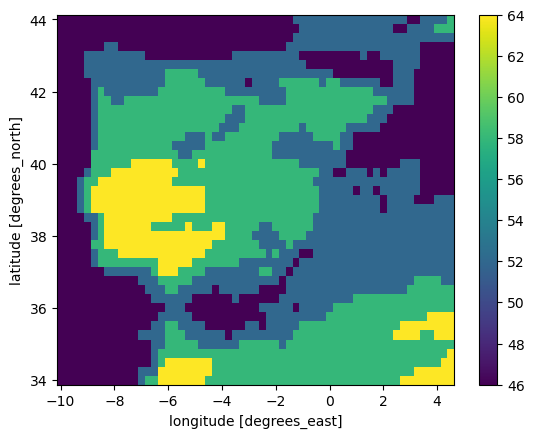

In [31]:
PG_grades.plot()